In [2]:
# ─── Cell 1: Install ────────────────────────────────────────────────────────────
!pip install imbalanced-learn kneed --quiet

In [3]:
# ─── Cell 2: Imports & Config ───────────────────────────────────────────────────
import os, glob, gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from imblearn.over_sampling import SMOTE
from sklearn.cluster import MiniBatchKMeans
from kneed import KneeLocator
from collections import defaultdict

# ── Paths ───────────────────────────────────────────────────────────────────────
input_folder  = '/content/drive/MyDrive/final_dataset/iot_cleaned_dedup'
output_folder = '/content/drive/MyDrive/final_dataset/iot_cleaned_sampled_kmeans_smote(40-40)'
bucket_dir    = '/content/buckets_kmeans'

# ── Sampling config ─────────────────────────────────────────────────────────────
target_col    = 'label'
DOWN_TARGET   = 40_000
UP_TARGET     = 40_000

# ── Elbow plot config ────────────────────────────────────────────────────────────
K_RANGE       = range(2, 21)          # K values to test in elbow plot
ELBOW_SAMPLE  = 50_000                # max rows to use for elbow computation (speed)

# ── After elbow: override K here if you want (None = use auto-detected elbow) ──
K_OVERRIDE    = None   # e.g. set to 10 to force k=10

os.makedirs(output_folder, exist_ok=True)
os.makedirs(bucket_dir,    exist_ok=True)

all_files = sorted(glob.glob(os.path.join(input_folder, '*.csv')))
print(f'Found {len(all_files)} files.')
print(f'Input  → {input_folder}')
print(f'Output → {output_folder}')

Found 62 files.
Input  → /content/drive/MyDrive/final_dataset/iot_cleaned_dedup
Output → /content/drive/MyDrive/final_dataset/iot_cleaned_sampled_kmeans_smote(40-40)


In [4]:
# ─── Cell 3: Pass 1 — Single-pass bucketing ─────────────────────────────────────
bucket_buffers = defaultdict(list)
FLUSH_EVERY    = 200_000
label_to_file  = {}

def get_bucket_path(label):
    if label not in label_to_file:
        idx  = len(label_to_file)
        safe = f'class_{idx:03d}.parquet'
        label_to_file[label] = os.path.join(bucket_dir, safe)
    return label_to_file[label]

def flush_to_disk(label, chunks):
    path   = get_bucket_path(label)
    new_df = pd.concat(chunks, ignore_index=True)
    if os.path.exists(path):
        existing = pd.read_parquet(path)
        new_df   = pd.concat([existing, new_df], ignore_index=True)
    new_df.to_parquet(path, index=False)

print('Pass 1: Bucketing rows by class...')
for file in tqdm(all_files, desc='Reading CSVs'):
    df = pd.read_csv(file)
    for label, group in df.groupby(target_col):
        bucket_buffers[label].append(group)
        total_buffered = sum(len(g) for g in bucket_buffers[label])
        if total_buffered >= FLUSH_EVERY:
            flush_to_disk(label, bucket_buffers[label])
            bucket_buffers[label] = []
    del df
    gc.collect()

print('Flushing remaining buffers...')
for label, chunks in bucket_buffers.items():
    if chunks:
        flush_to_disk(label, chunks)
bucket_buffers.clear()

print(f'\nBucketed {len(label_to_file)} classes.')

Pass 1: Bucketing rows by class...


Reading CSVs:   0%|          | 0/62 [00:00<?, ?it/s]

Flushing remaining buffers...

Bucketed 34 classes.


Elbow analysis on 50,000 rows × 39 features
Testing K = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] ...


Elbow KMeans:   0%|          | 0/19 [00:00<?, ?it/s]

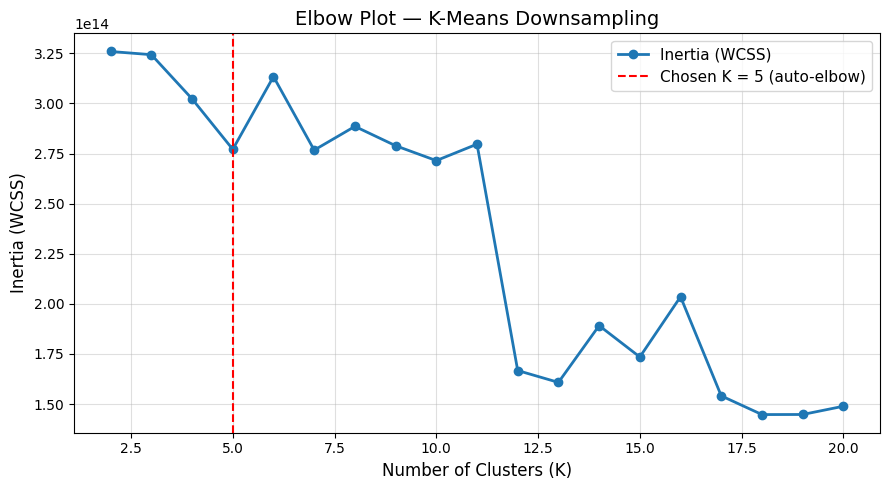


🔍 Auto-detected elbow at K = 5
✅ K_OPTIMAL used for downsampling = 5

💡 If the elbow looks wrong, set  K_OVERRIDE = <your_value>  in Cell 2 and re-run from Cell 4.


35

In [5]:
# ─── Cell 4: Elbow Plot — Find Optimal K for K-Means Downsampling ───────────────
#
# Strategy:
#   • Collect up to ELBOW_SAMPLE rows from classes that will be downsampled
#     (i.e., classes with >= DOWN_TARGET rows, excluding BENIGN)
#   • Run MiniBatchKMeans for each K in K_RANGE and record inertia (WCSS)
#   • Plot the elbow curve and auto-detect the knee point with KneeLocator
# ─────────────────────────────────────────────────────────────────────────────────

print('Collecting sample rows from large classes for elbow analysis...')
sample_frames = []
rows_collected = 0

for label, bucket_path in label_to_file.items():
    if rows_collected >= ELBOW_SAMPLE:
        break
    tmp = pd.read_parquet(bucket_path)
    if str(label).upper() == 'BENIGN' or len(tmp) < DOWN_TARGET:
        del tmp
        continue
    # Take a slice for elbow computation
    take = min(ELBOW_SAMPLE - rows_collected, 5_000)
    sample_frames.append(tmp.sample(n=take, random_state=42))
    rows_collected += take
    del tmp
    gc.collect()

if not sample_frames:
    raise RuntimeError(
        'No large classes found for elbow analysis. '
        'Check that some classes have >= DOWN_TARGET rows.'
    )

elbow_df = pd.concat(sample_frames, ignore_index=True)
del sample_frames
gc.collect()

# ── Prepare numeric feature matrix ──────────────────────────────────────────────
feature_cols_elbow = [c for c in elbow_df.columns if c != target_col]
X_elbow = elbow_df[feature_cols_elbow].select_dtypes(include=[np.number]).copy()
X_elbow.replace([np.inf, -np.inf], np.nan, inplace=True)
X_elbow.fillna(X_elbow.median(), inplace=True)
X_elbow = X_elbow.clip(
    lower=np.finfo(np.float32).min / 2,
    upper=np.finfo(np.float32).max / 2
).astype('float32')

print(f'Elbow analysis on {len(X_elbow):,} rows × {X_elbow.shape[1]} features')
print(f'Testing K = {list(K_RANGE)} ...')

# ── Run KMeans for each K ────────────────────────────────────────────────────────
inertias = []
for k in tqdm(K_RANGE, desc='Elbow KMeans'):
    km = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        n_init=3,
        max_iter=300,
        batch_size=min(10_000, len(X_elbow))
    )
    km.fit(X_elbow)
    inertias.append(km.inertia_)

# ── Auto-detect elbow with KneeLocator ──────────────────────────────────────────
kl = KneeLocator(
    list(K_RANGE), inertias,
    curve='convex', direction='decreasing'
)
K_AUTO = kl.knee if kl.knee is not None else int(np.median(list(K_RANGE)))
K_OPTIMAL = K_OVERRIDE if K_OVERRIDE is not None else K_AUTO

# ── Plot ─────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(K_RANGE), inertias, marker='o', linewidth=2, label='Inertia (WCSS)')
ax.axvline(x=K_OPTIMAL, color='red', linestyle='--', linewidth=1.5,
           label=f'Chosen K = {K_OPTIMAL} ({"override" if K_OVERRIDE else "auto-elbow"})')
ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('Inertia (WCSS)', fontsize=12)
ax.set_title('Elbow Plot — K-Means Downsampling', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f'\n🔍 Auto-detected elbow at K = {K_AUTO}')
print(f'✅ K_OPTIMAL used for downsampling = {K_OPTIMAL}')
print()
print('💡 If the elbow looks wrong, set  K_OVERRIDE = <your_value>  in Cell 2 and re-run from Cell 4.')

del elbow_df, X_elbow
gc.collect()

In [7]:
# ─── Cell 5: Pass 2 — Balance each class ────────────────────────────────────────
#
# Downsampling strategy (K-Means):
#   1. Cluster the class into K_OPTIMAL clusters using MiniBatchKMeans
#   2. Proportionally sample from each cluster to reach DOWN_TARGET rows
#   3. Adjust final count to exactly DOWN_TARGET (trim/fill as needed)
# ─────────────────────────────────────────────────────────────────────────────────

def kmeans_downsample(class_df, target_n, k, feature_cols, label_val, random_state=42):
    """
    Downsample class_df to exactly target_n rows using K-Means cluster-proportional sampling.
    """
    X = class_df[feature_cols].select_dtypes(include=[np.number]).copy()
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    X.fillna(X.median(), inplace=True)
    X = X.clip(
        lower=np.finfo(np.float32).min / 2,
        upper=np.finfo(np.float32).max / 2
    ).astype('float32')

    # Clamp K to available rows
    effective_k = min(k, len(class_df))

    km = MiniBatchKMeans(
        n_clusters=effective_k,
        random_state=random_state,
        n_init=3,
        max_iter=300,
        batch_size=min(10_000, len(class_df))
    )
    cluster_labels = km.fit_predict(X)

    df_clustered = class_df.copy()
    df_clustered['__cluster__'] = cluster_labels

    # ── Proportional sampling per cluster ────────────────────────────────────────
    total = len(df_clustered)
    sampled_parts = []
    for cid, cgroup in df_clustered.groupby('__cluster__', sort=False):
        n_take = max(1, round(target_n * len(cgroup) / total))
        replace = len(cgroup) < n_take
        sampled_parts.append(
            cgroup.sample(n=n_take, random_state=random_state, replace=replace)
        )

    sampled = pd.concat(sampled_parts, ignore_index=True)
    sampled.drop(columns=['__cluster__'], inplace=True)

    # ── Trim or fill to hit exact target ────────────────────────────────────────
    if len(sampled) > target_n:
        sampled = sampled.sample(n=target_n, random_state=random_state).reset_index(drop=True)
    elif len(sampled) < target_n:
        deficit = target_n - len(sampled)
        extra   = class_df.drop(
            index=sampled.index, errors='ignore'
        ).sample(n=deficit, random_state=random_state, replace=True)
        sampled = pd.concat([sampled, extra], ignore_index=True)

    return sampled


# ─────────────────────────────────────────────────────────────────────────────────
print(f'Pass 2: Balancing each class  (K_OPTIMAL = {K_OPTIMAL})...')

for label, bucket_path in tqdm(label_to_file.items(), desc='Balancing Classes'):
    class_df      = pd.read_parquet(bucket_path)
    current_count = len(class_df)
    actual_label  = class_df[target_col].iloc[0]

    print(f"\n  '{actual_label}': {current_count:,} rows")

    # ── BENIGN: keep all rows ───────────────────────────────────────────────────
    if str(actual_label).upper() == 'BENIGN':
        final_df = class_df.copy()
        print(f'  → Kept as-is (BENIGN, {current_count:,} rows)')

    # ── CASE 1: K-Means Downsample ─────────────────────────────────────────────
    elif current_count >= DOWN_TARGET:
        feature_cols = [c for c in class_df.columns if c != target_col]
        final_df = kmeans_downsample(
            class_df, DOWN_TARGET, K_OPTIMAL,
            feature_cols, actual_label, random_state=42
        )
        # Restore label column (may have been dropped if not numeric)
        if target_col not in final_df.columns:
            final_df[target_col] = actual_label
        print(f'  → K-Means downsampled to {len(final_df):,}  (K={K_OPTIMAL})')

    # ── CASE 2: Too few for SMOTE ──────────────────────────────────────────────
    elif current_count < 6:
        final_df = class_df.sample(n=UP_TARGET, replace=True, random_state=42)
        print(f'  → Random oversample to {UP_TARGET:,}')

    # ── CASE 3: SMOTE upsample ─────────────────────────────────────────────────
    else:
        feature_cols = [c for c in class_df.columns if c != target_col]
        k_neighbors  = min(5, current_count - 1)

        X_real = class_df[feature_cols].select_dtypes(include=[np.number]).copy()
        X_real.replace([np.inf, -np.inf], np.nan, inplace=True)
        X_real.fillna(X_real.median(), inplace=True)
        X_real = X_real.clip(
            lower=np.finfo(np.float32).min / 2,
            upper=np.finfo(np.float32).max / 2
        ).astype('float32')

        dummy_df   = X_real.sample(n=min(k_neighbors + 1, current_count), random_state=0).copy()
        X_combined = pd.concat([X_real, dummy_df], ignore_index=True)
        y_combined = pd.Series(
            [actual_label] * len(X_real) + ['__DUMMY__'] * len(dummy_df)
        )

        try:
            sm = SMOTE(
                sampling_strategy={actual_label: UP_TARGET},
                k_neighbors=k_neighbors,
                random_state=42
            )
            X_res, y_res = sm.fit_resample(X_combined, y_combined)

            final_df = X_res[y_res == actual_label].copy()
            final_df[target_col] = actual_label
            print(f'  → SMOTE upsampled to {len(final_df):,}')

        except Exception as e:
            print(f'  ⚠ SMOTE failed ({e}), using random oversample.')
            final_df = class_df.sample(n=UP_TARGET, replace=True, random_state=42)

    # ── Save ────────────────────────────────────────────────────────────────────
    safe_label = str(actual_label).replace(' ', '_').replace('/', '-')
    out_path   = os.path.join(output_folder, f'{safe_label}.csv')
    final_df.to_csv(out_path, index=False)
    print(f'  ✅ Saved → {out_path}')

    del class_df, final_df
    gc.collect()

print(f'\n✅ Done! Output: {output_folder}')

Pass 2: Balancing each class  (K_OPTIMAL = 5)...


Balancing Classes:   0%|          | 0/34 [00:00<?, ?it/s]


  'DDOS-ICMP_FLOOD': 2,020,984 rows
  → K-Means downsampled to 40,000  (K=5)
  ✅ Saved → /content/drive/MyDrive/final_dataset/iot_cleaned_sampled_kmeans_smote(40-40)/DDOS-ICMP_FLOOD.csv

  'DDOS-UDP_FLOOD': 1,967,818 rows
  → K-Means downsampled to 40,000  (K=5)
  ✅ Saved → /content/drive/MyDrive/final_dataset/iot_cleaned_sampled_kmeans_smote(40-40)/DDOS-UDP_FLOOD.csv

  'DDOS-PSHACK_FLOOD': 1,730,270 rows
  → K-Means downsampled to 40,000  (K=5)
  ✅ Saved → /content/drive/MyDrive/final_dataset/iot_cleaned_sampled_kmeans_smote(40-40)/DDOS-PSHACK_FLOOD.csv

  'DDOS-SYN_FLOOD': 1,827,885 rows
  → K-Means downsampled to 40,000  (K=5)
  ✅ Saved → /content/drive/MyDrive/final_dataset/iot_cleaned_sampled_kmeans_smote(40-40)/DDOS-SYN_FLOOD.csv

  'DDOS-TCP_FLOOD': 1,611,482 rows
  → K-Means downsampled to 40,000  (K=5)
  ✅ Saved → /content/drive/MyDrive/final_dataset/iot_cleaned_sampled_kmeans_smote(40-40)/DDOS-TCP_FLOOD.csv

  'DOS-UDP_FLOOD': 1,769,959 rows
  → K-Means downsampled to 40,00

In [1]:
# ─── Cell 6: Verify — Final Class Distribution ──────────────────────────────────
import pandas as pd
import glob
import os

balanced_folder      = '/content/drive/MyDrive/final_dataset/iot_cleaned_sampled_kmeans_smote(40-40)'
all_balanced_files   = glob.glob(os.path.join(balanced_folder, '*.csv'))

distribution = {}

print('Calculating final distribution...')
for file in all_balanced_files:
    df_temp = pd.read_csv(file)
    label   = df_temp['label'].iloc[0] if not df_temp.empty else os.path.basename(file)
    distribution[label] = len(df_temp)

dist_series = pd.Series(distribution).sort_values(ascending=False)
print('\n' + '='*30)
print('FINAL CLASS DISTRIBUTION')
print('='*30)
print(dist_series)
print('='*30)
print(f'Total rows in balanced dataset: {dist_series.sum():,}')

Calculating final distribution...

FINAL CLASS DISTRIBUTION
BENIGN                     1026628
DDOS-ICMP_FLOOD              40000
DDOS-UDP_FLOOD               40000
DDOS-PSHACK_FLOOD            40000
DDOS-TCP_FLOOD               40000
DDOS-SYN_FLOOD               40000
DDOS-RSTFINFLOOD             40000
DDOS-SYNONYMOUSIP_FLOOD      40000
DOS-TCP_FLOOD                40000
DOS-UDP_FLOOD                40000
DOS-SYN_FLOOD                40000
MIRAI-GREETH_FLOOD           40000
MIRAI-UDPPLAIN               40000
MIRAI-GREIP_FLOOD            40000
DDOS-ICMP_FRAGMENTATION      40000
VULNERABILITYSCAN            40000
DDOS-ACK_FRAGMENTATION       40000
DDOS-UDP_FRAGMENTATION       40000
MITM-ARPSPOOFING             40000
BACKDOOR_MALWARE             40000
BROWSERHIJACKING             40000
COMMANDINJECTION             40000
DDOS-HTTP_FLOOD              40000
DDOS-SLOWLORIS               40000
DICTIONARYBRUTEFORCE         40000
DNS_SPOOFING                 40000
DOS-HTTP_FLOOD               4

In [2]:
# ─── Cell 7: Verify — Duplicate Check per Class ─────────────────────────────────
import gc

print('Checking for exact duplicates per class...')
print(f"{'Class Label':<30} | {'Total Rows':<12} | {'Unique Rows':<12} | {'Duplicates':<10}")
print('-' * 75)

for file in sorted(all_balanced_files):
    df_check   = pd.read_csv(file)
    label      = df_check['label'].iloc[0] if not df_check.empty else os.path.basename(file)
    total      = len(df_check)
    unique_cnt = len(df_check.drop_duplicates())
    duplicates = total - unique_cnt
    print(f"{str(label)[:30]:<30} | {total:<12,} | {unique_cnt:<12,} | {duplicates:<10,}")
    del df_check
    gc.collect()

Checking for exact duplicates per class...
Class Label                    | Total Rows   | Unique Rows  | Duplicates
---------------------------------------------------------------------------
BACKDOOR_MALWARE               | 40,000       | 39,990       | 10        
BENIGN                         | 1,026,628    | 1,026,168    | 460       
BROWSERHIJACKING               | 40,000       | 39,871       | 129       
COMMANDINJECTION               | 40,000       | 39,810       | 190       
DDOS-ACK_FRAGMENTATION         | 40,000       | 39,994       | 6         
DDOS-HTTP_FLOOD                | 40,000       | 40,000       | 0         
DDOS-ICMP_FLOOD                | 40,000       | 39,932       | 68        
DDOS-ICMP_FRAGMENTATION        | 40,000       | 39,999       | 1         
DDOS-PSHACK_FLOOD              | 40,000       | 39,908       | 92        
DDOS-RSTFINFLOOD               | 40,000       | 39,847       | 153       
DDOS-SLOWLORIS                 | 40,000       | 40,000       | 0   

In [3]:
# ─── Cell 8: Merge + Multi-pass Shuffle ─────────────────────────────────────────
import pandas as pd
import glob
import os
import gc
import numpy as np

balanced_folder = '/content/drive/MyDrive/final_dataset/iot_cleaned_sampled_kmeans_smote(40-40)'
output_path     = os.path.join(balanced_folder, 'merged.csv')

all_files = glob.glob(os.path.join(balanced_folder, '*.csv'))
all_files = [f for f in all_files if os.path.basename(f) != 'merged.csv']

print(f'Found {len(all_files)} class files to merge.')

dfs = []
for file in all_files:
    df = pd.read_csv(file)
    dfs.append(df)
    print(f'  Loaded: {os.path.basename(file)} → {len(df):,} rows')
    gc.collect()

print('\nConcatenating all classes...')
merged = pd.concat(dfs, ignore_index=True)
del dfs
gc.collect()

print(f'Total rows before shuffle: {len(merged):,}')

# ── Rigorous multi-pass shuffle ──────────────────────────────────────────────────
print('\nShuffling (pass 1/3)...')
merged = merged.sample(frac=1, random_state=42).reset_index(drop=True)

print('Shuffling (pass 2/3)...')
merged = merged.sample(frac=1, random_state=np.random.randint(0, 99999)).reset_index(drop=True)

print('Shuffling (pass 3/3)...')
merged = merged.sample(frac=1, random_state=np.random.randint(0, 99999)).reset_index(drop=True)

print(f'\nFinal label distribution:\n{merged["label"].value_counts()}')
print(f'\nTotal rows: {len(merged):,}')

print(f'\nSaving to {output_path} ...')
merged.to_csv(output_path, index=False)
print('✅ Done! Merged and shuffled CSV saved successfully.')

Found 34 class files to merge.
  Loaded: DDOS-ICMP_FLOOD.csv → 40,000 rows
  Loaded: DDOS-UDP_FLOOD.csv → 40,000 rows
  Loaded: DDOS-PSHACK_FLOOD.csv → 40,000 rows
  Loaded: DDOS-SYN_FLOOD.csv → 40,000 rows
  Loaded: DDOS-TCP_FLOOD.csv → 40,000 rows
  Loaded: DOS-UDP_FLOOD.csv → 40,000 rows
  Loaded: DDOS-RSTFINFLOOD.csv → 40,000 rows
  Loaded: DDOS-SYNONYMOUSIP_FLOOD.csv → 40,000 rows
  Loaded: DOS-TCP_FLOOD.csv → 40,000 rows
  Loaded: DOS-SYN_FLOOD.csv → 40,000 rows
  Loaded: BENIGN.csv → 1,026,628 rows
  Loaded: MIRAI-GREETH_FLOOD.csv → 40,000 rows
  Loaded: MIRAI-UDPPLAIN.csv → 40,000 rows
  Loaded: MIRAI-GREIP_FLOOD.csv → 40,000 rows
  Loaded: DDOS-ICMP_FRAGMENTATION.csv → 40,000 rows
  Loaded: VULNERABILITYSCAN.csv → 40,000 rows
  Loaded: DDOS-ACK_FRAGMENTATION.csv → 40,000 rows
  Loaded: DDOS-UDP_FRAGMENTATION.csv → 40,000 rows
  Loaded: MITM-ARPSPOOFING.csv → 40,000 rows
  Loaded: BACKDOOR_MALWARE.csv → 40,000 rows
  Loaded: BROWSERHIJACKING.csv → 40,000 rows
  Loaded: COMMANDI